In [1]:
#python imports
import numpy as np
import pylab as plt
import pickle
from scipy.integrate import quad
from scipy.interpolate import interp1d

#From this code
import constants
import kinematics
import etcross
%matplotlib inline

In [2]:
T = 18e3   # Default electron energy

# Inelastic to discrete

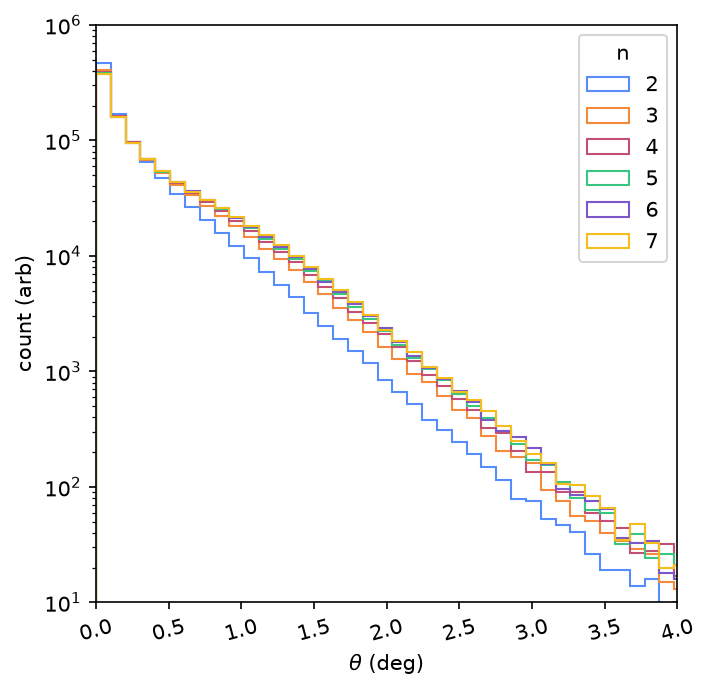

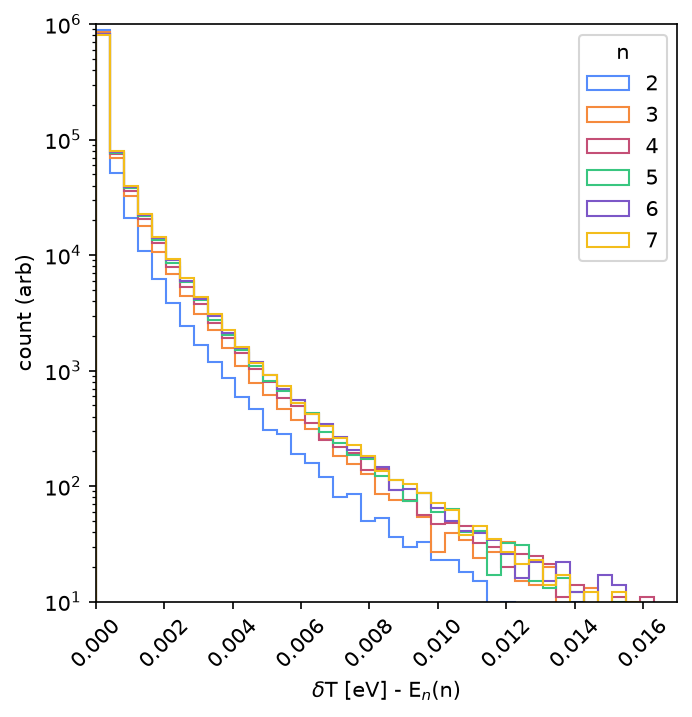

In [3]:
SampleDict=etcross.MakeSampleDicitonary(T,constants.movM,ns=range(2,8))


plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(np.arccos(kinematics.getCosTheta(Ka2,T,kinematics.En(n)))*180/np.pi,bins=np.linspace(0,5,50),label=n,histtype='step')
    #plt.hist(Ka2,bins=np.linspace(0,15,100),histtype='step')

plt.ylim(10,1e6)
plt.xlim(0,4)
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel("count (arb)")
plt.xticks(rotation=15)
plt.semilogy()
plt.legend(loc='upper right',title='n')
plt.show()

plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(kinematics.getDeltaT(Ka2,kinematics.En(n))-kinematics.En(n),bins=np.linspace(0,0.02,50),label=n,histtype='step')


plt.legend(loc='upper right',title='n')
plt.xlabel(r"$\delta$T [eV] - E$_n$(n)" )
plt.ylabel("count (arb)")
plt.xlim(0,0.017)
plt.ylim(10,1e6)
plt.xticks(rotation=45)
plt.semilogy()
plt.show()


# Continuum contribution

In [4]:
# Make inelastic distribution
Emin=1.00001
Emax=10
logKa2min=-9
logKa2max=6
EE,KK           = np.meshgrid(np.linspace(Emin,Emax,100),np.linspace(logKa2min,logKa2max,100))
Distn_continuum = etcross.DistributionDraw(EE,KK,T,constants.movM)

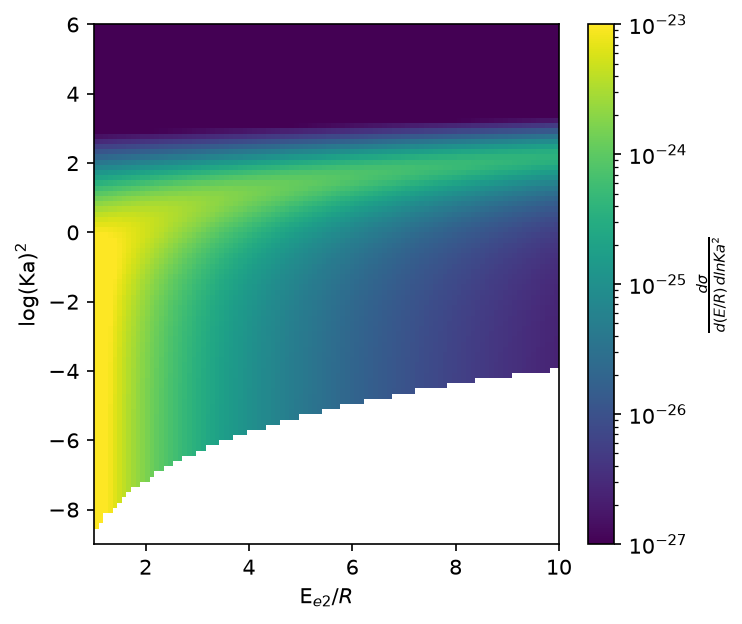

In [5]:

plt.figure(figsize=(5,4.5),dpi=150)
plt.imshow(Distn_continuum,extent=[np.min(EE),np.max(EE),np.min(KK),np.max(KK)],aspect='auto',origin='lower',norm='log',vmin=1e-27,vmax=1e-23)
plt.colorbar(label=r"$\frac{d\sigma}{d(E/R)\,dln Ka^2}$")
#plt.clim(0,1e-23)
plt.xlabel('E$_{e2}/R$')
plt.ylabel(r'log(Ka)$^2$')
plt.xlim(1,10)
plt.show()


/Users/benjpjones/Documents/Work/Project8ElectronScattering/etcross.py:114: RuntimeWarning: invalid value encountered in arccos
  theta= np.arccos(kinematics.getCosTheta(np.exp(logK),T,E*constants.R))


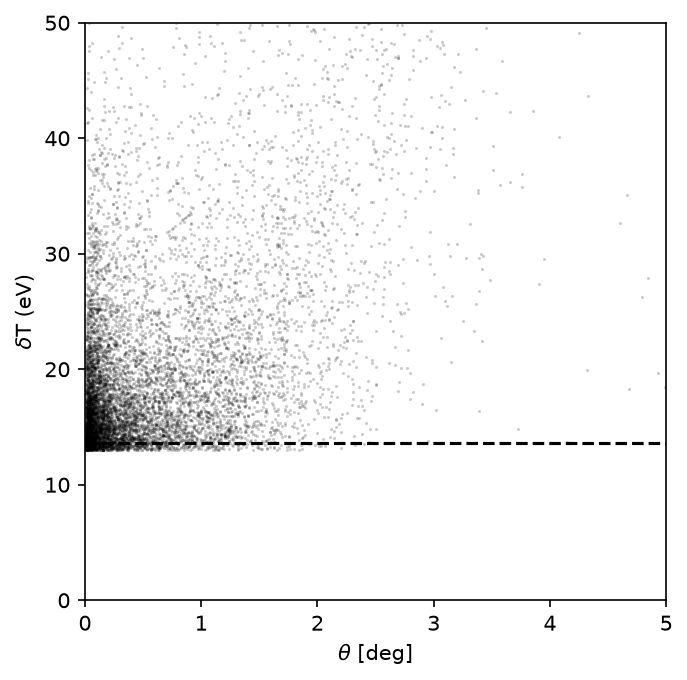

In [6]:
plt.figure(figsize=(5,5),dpi=150)
samples=10000
theta,dT,E,logK=etcross.SampleContinuum(T,Distn_continuum,Emin,Emax,logKa2min,logKa2max,samples=samples)
plt.plot(theta*180/np.pi,dT,'.',alpha=0.2,markersize=1,color='black')
plt.xlabel(r"$\theta$ [deg]")
plt.ylabel(r"$\delta$T (eV)")
plt.xlim(0,5)
plt.plot([0,7],[13.6,13.6],'--',color='black')
plt.ylim(0,50)
plt.show()

# Elastic

In [7]:
SampleFunc=etcross.MakeSampleFunction_elastic(T,constants.movM)
Ka2_el=etcross.GetRandomKa2_elastic(SampleFunc,1000000)

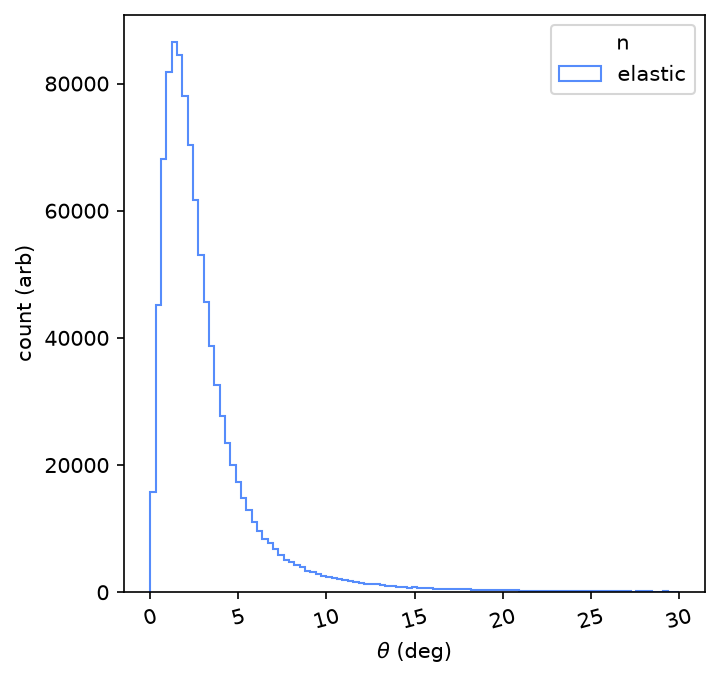

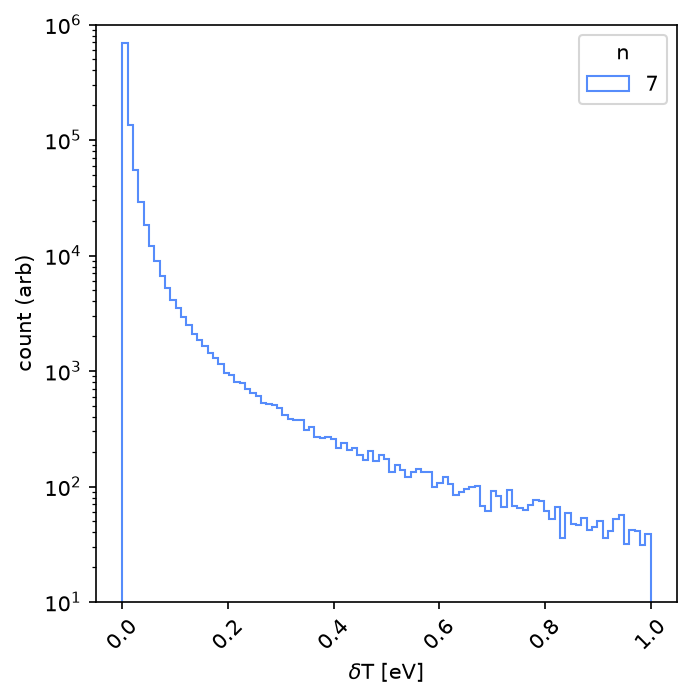

In [8]:
plt.figure(figsize=(5,5),dpi=150)

plt.hist(np.arccos(kinematics.getCosTheta(Ka2_el,T,0))*180/np.pi,bins=np.linspace(0,30,100),label='elastic',histtype='step')
plt.xlabel(r"$\theta$ (deg)")
plt.ylabel("count (arb)")
plt.xticks(rotation=15)
plt.legend(loc='upper right',title='n')
plt.show()
plt.figure(figsize=(5,5),dpi=150)
plt.hist(kinematics.getDeltaT(Ka2_el,0),bins=np.linspace(0,1,100),label=n,histtype='step')


plt.legend(loc='upper right',title='n')
plt.xlabel(r"$\delta$T [eV]" )
plt.ylabel("count (arb)")
#plt.xlim(0,0.017)
plt.ylim(10,1e6)
plt.xticks(rotation=45)
plt.semilogy()
plt.show()


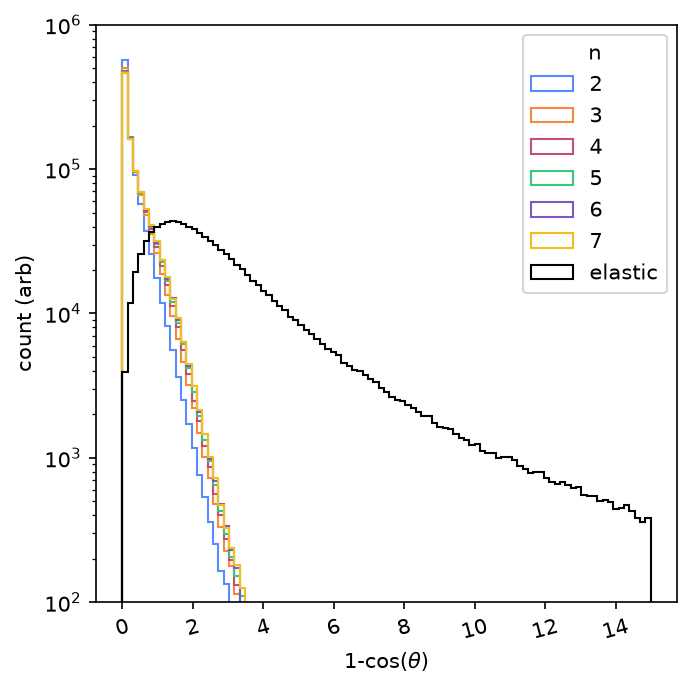

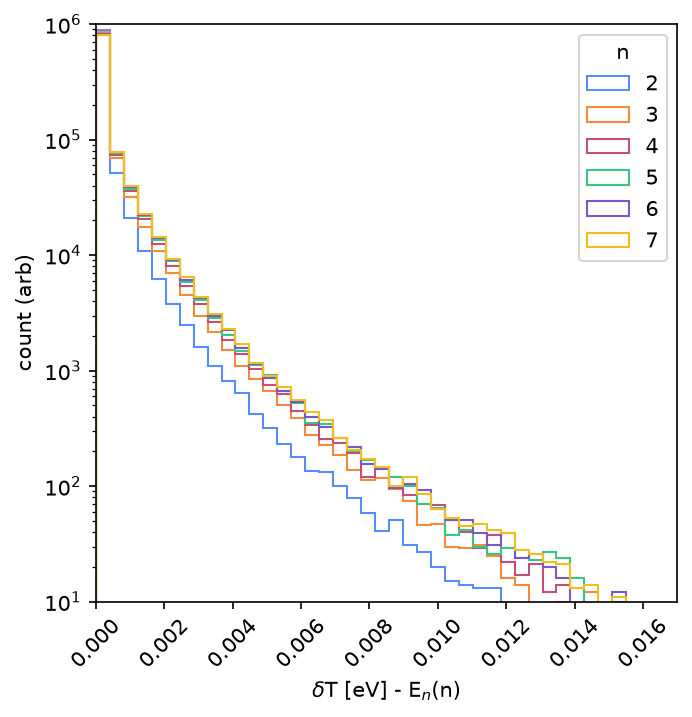

In [9]:
n=2
SampleDict=etcross.MakeSampleDicitonary(T,constants.movM,ns=range(2,8))

TopAngle=15
plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(np.arccos(kinematics.getCosTheta(Ka2,T,kinematics.En(n)))*180/np.pi,bins=np.linspace(0,TopAngle,100),label=n,histtype='step')
    #plt.hist(Ka2,bins=np.linspace(0,15,100),histtype='step')
plt.hist(np.arccos(kinematics.getCosTheta(Ka2_el,T,0))*180/np.pi,bins=np.linspace(0,TopAngle,100),label='elastic',histtype='step',color='black')

plt.xlabel(r"1-cos($\theta$)")
plt.ylabel("count (arb)")
plt.xticks(rotation=15)
plt.ylim(1e2, 1e6)

plt.semilogy()
plt.legend(loc='upper right',title='n')
plt.show()

plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(kinematics.getDeltaT(Ka2,kinematics.En(n))-kinematics.En(n),bins=np.linspace(0,0.02,50),label=n,histtype='step')

plt.legend(loc='upper right',title='n')
plt.xlabel(r"$\delta$T [eV] - E$_n$(n)" )
plt.ylabel("count (arb)")
plt.xlim(0,0.017)
plt.ylim(10,1e6)
plt.xticks(rotation=45)
plt.semilogy()
plt.show()


# Combo plots

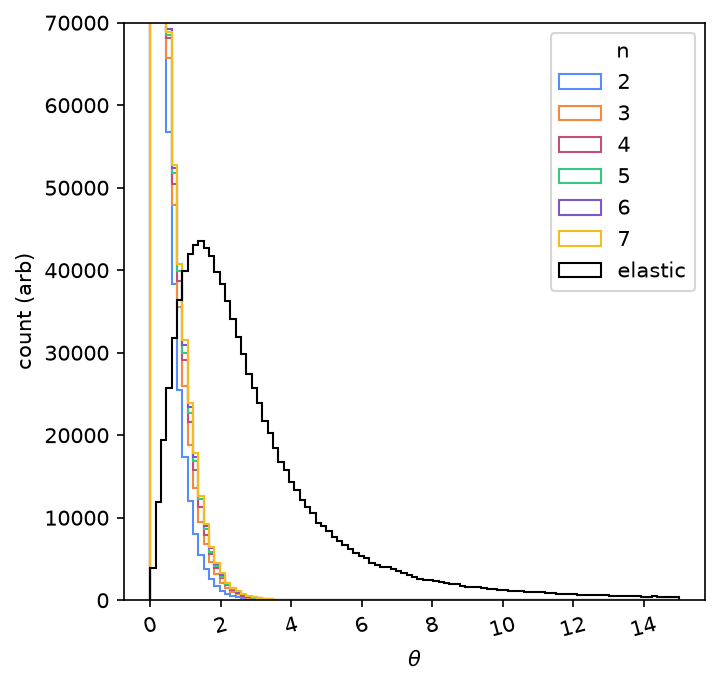

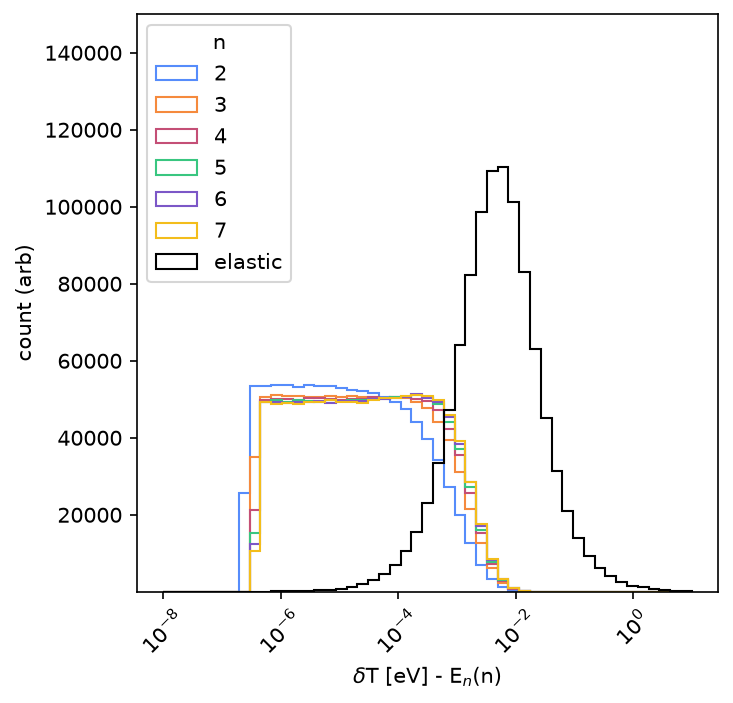

In [10]:
n=2
SampleDict=etcross.MakeSampleDicitonary(T,constants.movM,ns=range(2,8))

TopAngle=15
plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(np.arccos(kinematics.getCosTheta(Ka2,T,kinematics.En(n)))*180/np.pi,bins=np.linspace(0,TopAngle,100),label=n,histtype='step')
    #plt.hist(Ka2,bins=np.linspace(0,15,100),histtype='step')
plt.hist(np.arccos(kinematics.getCosTheta(Ka2_el,T,0))*180/np.pi,bins=np.linspace(0,TopAngle,100),label='elastic',histtype='step',color='black')

plt.xlabel(r"$\theta$")
plt.ylabel("count (arb)")
plt.xticks(rotation=15)
plt.ylim(0,7e4)

plt.legend(loc='upper right',title='n')
plt.show()
TopE=0.025
plt.figure(figsize=(5,5),dpi=150)
for n in SampleDict.keys():
    Ka2=etcross.GetRandomKa2_discrete(n,SampleDict,1000000)
    plt.hist(kinematics.getDeltaT(Ka2,kinematics.En(n)-kinematics.En(n)),bins=np.logspace(-8,1,50),label=n,histtype='step')
plt.hist(kinematics.getDeltaT(Ka2_el,0),bins=np.logspace(-8,1,50),label='elastic',histtype='step',color='black')
plt.semilogx()

plt.legend(loc='upper left',title='n')
plt.xlabel(r"$\delta$T [eV] - E$_n$(n)" )
plt.ylabel("count (arb)")
#plt.xlim(0,0.017)
plt.ylim(10,1.5e5)
plt.xticks(rotation=45)
plt.show()


# Total Cross Sections

In [11]:
TotalCrossSections={}
Ts=np.linspace(1e2,20e3,100)

#Discrete cross sections
for n in range(2,10):
    sig=[]

    for T in Ts:
        ln_qmin2=np.log(kinematics.Ka2Min(kinematics.En(n),T,constants.movM))
        ln_qmax2=np.log(kinematics.Ka2Max(kinematics.En(n),T,constants.movM))
        def ToInt(lnKa2):
            return etcross.dsigdLnKa_discrete(T,n,lnKa2)
        sig.append(quad(ToInt,ln_qmin2,ln_qmax2)[0])
    TotalCrossSections["discrete_"+str(n)]=interp1d(Ts,sig)

sigma_cont=[etcross.sig_continuum(T) for T in Ts]
TotalCrossSections["continuum"]=interp1d(Ts,sigma_cont)

TotalCrossSections["elastic"]=interp1d(Ts,etcross.sig_elastic(Ts))

In [12]:
# Save total cross sections to file
f=open("./TotalCrossSections.pkl",'wb')
pickle.dump(TotalCrossSections,f)
f.close()

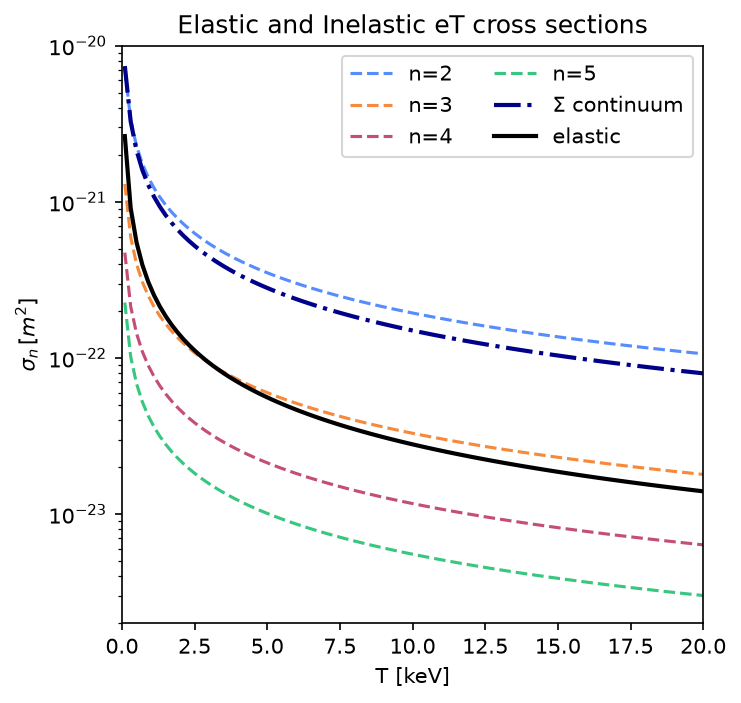

In [13]:
plt.figure(figsize=(5,5),dpi=150)
Ts=np.linspace(1e2,20e3,100)

#Discrete cross sections
for n in range(2,6):
    plt.plot(Ts/1000,TotalCrossSections["discrete_"+str(n)](Ts),'--',label="n="+str(n))

plt.plot(Ts/1000,TotalCrossSections["continuum"](Ts),'-.',color='DarkBlue',linewidth=2,label=r'$\Sigma$ continuum')
plt.plot(Ts/1000,TotalCrossSections["elastic"](Ts),'-',color='black',label='elastic',linewidth=2)
plt.semilogy()
plt.legend(loc='upper right',ncol=2)
plt.xlabel("T [keV]")
plt.ylabel(r"$\sigma_n\, [m^2]$")
plt.title(r"Elastic and Inelastic eT cross sections")
plt.xlim(0,20)
plt.ylim(2e-24,1e-20)
plt.show()
